# 02 - Pretprocesiranje Teksta

**Cilj**: Očistiti i pripremiti tekstualne podatke za modelovanje

**Koraci**:
1. Učitaj očišćene podatke iz Notebook 01
2. Primeni text preprocessing
3. Kreiraj train/test split
4. Sačuvaj preprocesirane podatke

In [1]:
# Import biblioteka
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

from preprocessing import TextPreprocessor, download_nltk_resources
from utils import save_model, set_style

# Postavi stil
set_style()

print("Biblioteke učitane!")

Biblioteke učitane!


In [2]:
# Download NLTK resursa (pokrenuti samo prvi put)
download_nltk_resources()

✅ NLTK resursi preuzeti uspešno


## 1. Učitavanje Podataka

In [3]:
# Učitaj clean dataset iz Notebook 01
df = pd.read_csv('../data/processed/bitcoin_tweets_clean.csv')

print(f"Učitano {len(df)} redova")
print(f"Kolone: {df.columns.tolist()}")

Učitano 97 redova
Kolone: ['text', 'sentiment', 'timestamp', 'user', 'text_length', 'word_count']


In [4]:
# POSTAVI NAZIVE KOLONA prema tvom datasetu
TEXT_COLUMN = 'text'  # <-- IZMENI ako treba!
SENTIMENT_COLUMN = 'sentiment'  # <-- IZMENI ako treba!

print(f"\nPrvih 5 redova:")
df.head()


Prvih 5 redova:


,text,sentiment,timestamp,user,text_length,word_count
0,Bitcoin is going to the moon! Best investment ...,positive,2024-01-15 10:30:00,crypto_bull,50,9
1,I lost so much money on BTC. This is terrible,negative,2024-01-15 11:45:00,sad_trader,45,10
2,Bitcoin price is stable today. Nothing much ha...,neutral,2024-01-15 12:00:00,observer123,53,8
3,Just bought more Bitcoin! Feeling bullish,positive,2024-01-15 13:20:00,hodler_4life,41,6
4,BTC crash incoming. Sell everything now!,negative,2024-01-15 14:10:00,bear_market,40,6


## 2. Primer Pre i Posle Preprocessinga

In [5]:
# Inicijalizuj preprocessor
preprocessor = TextPreprocessor(
    lowercase=True,
    remove_urls=True,
    remove_mentions=True,
    remove_hashtags=True,
    remove_numbers=True,
    remove_punctuation=True,
    remove_stopwords=True,
    stemming=False,
    lemmatization=True
)

print("TextPreprocessor inicijalizovan!")
print(f"\nParametri:")
print(f"  - lowercase: True")
print(f"  - remove_urls: True")
print(f"  - remove_mentions: True")
print(f"  - remove_hashtags: True")
print(f"  - remove_stopwords: True")
print(f"  - lemmatization: True")

TextPreprocessor inicijalizovan!

Parametri:
  - lowercase: True
  - remove_urls: True
  - remove_mentions: True
  - remove_hashtags: True
  - remove_stopwords: True
  - lemmatization: True


In [6]:
# Test preprocessing na 3 primera
print("\n" + "="*80)
print("PRIMERI PREPROCESSINGA")
print("="*80)

for i, row in df.sample(3).iterrows():
    original = row[TEXT_COLUMN]
    cleaned = preprocessor.preprocess(original)
    
    print(f"\n[Primer {i}]")
    print(f"Original:  {original}")
    print(f"Cleaned:   {cleaned}")
    print("-" * 80)


PRIMERI PREPROCESSINGA

[Primer 16]
Original:  Another exchange hack. Bitcoin is not safe
Cleaned:   another exchange hack bitcoin safe
--------------------------------------------------------------------------------

[Primer 6]
Original:  Bitcoin adoption is growing. Major companies accepting it now
Cleaned:   bitcoin adoption growing major company accepting
--------------------------------------------------------------------------------

[Primer 20]
Original:  Bitcoin whitepaper anniversary today. 15 years
Cleaned:   bitcoin whitepaper anniversary today year
--------------------------------------------------------------------------------


## 3. Preprocessing Celog Dataseta

**⏱️ Ovo može potrajati nekoliko minuta za veće dataset-e!**

In [7]:
# Primeni preprocessing na ceo dataset
from tqdm import tqdm
tqdm.pandas()

print("Preprocessing u toku...")
df['cleaned_text'] = df[TEXT_COLUMN].progress_apply(preprocessor.preprocess)
print("\n✅ Preprocessing završen!")

Preprocessing u toku...


100%|██████████| 97/97 [00:00<00:00, 15359.11it/s]


✅ Preprocessing završen!


In [8]:
# Provera da li ima praznih tekstova nakon preprocessinga
empty_texts = df[df['cleaned_text'].str.strip() == '']
print(f"Broj praznih tekstova nakon preprocessinga: {len(empty_texts)}")

if len(empty_texts) > 0:
    print(f"\nUklanjam {len(empty_texts)} praznih tekstova...")
    df = df[df['cleaned_text'].str.strip() != '']
    print(f"Preostalo redova: {len(df)}")
else:
    print("✅ Nema praznih tekstova!")

Broj praznih tekstova nakon preprocessinga: 0
✅ Nema praznih tekstova!


## 4. Još Nekoliko Primera

In [9]:
# Prikaži random primere
print("\n" + "="*80)
print("RANDOM PRIMERI (Original vs Cleaned)")
print("="*80)

for i, row in df.sample(5).iterrows():
    print(f"\n[Tweet {i}]")
    print(f"Original: {row[TEXT_COLUMN]}")
    print(f"Cleaned:  {row['cleaned_text']}")
    if SENTIMENT_COLUMN in df.columns:
        print(f"Sentiment: {row[SENTIMENT_COLUMN]}")
    print("-" * 80)


RANDOM PRIMERI (Original vs Cleaned)

[Tweet 43]
Original: Central banks trying to kill Bitcoin with CBDC
Cleaned:  central bank trying kill bitcoin cbdc
Sentiment: negative
--------------------------------------------------------------------------------

[Tweet 31]
Original: Tether FUD spreading again. Bitcoin going down
Cleaned:  tether fud spreading bitcoin going
Sentiment: negative
--------------------------------------------------------------------------------

[Tweet 47]
Original: Average Bitcoin transaction size is 500 bytes
Cleaned:  average bitcoin transaction size byte
Sentiment: neutral
--------------------------------------------------------------------------------

[Tweet 95]
Original: Bitcoin rainbow chart suggests accumulation phase
Cleaned:  bitcoin rainbow chart suggests accumulation phase
Sentiment: neutral
--------------------------------------------------------------------------------

[Tweet 34]
Original: Bitcoin is a ponzi scheme. Change my mind
Cleaned:  bitcoin

## 5. Statistika Pre i Posle

In [10]:
# Dužina pre i posle preprocessinga
df['original_length'] = df[TEXT_COLUMN].apply(len)
df['cleaned_length'] = df['cleaned_text'].apply(len)

print("\n📊 STATISTIKA DUŽINE TEKSTA")
print("="*50)
print(f"\nPRE preprocessinga:")
print(f"  Prosečna dužina: {df['original_length'].mean():.1f} karaktera")
print(f"  Min: {df['original_length'].min()} | Max: {df['original_length'].max()}")

print(f"\nPOSLE preprocessinga:")
print(f"  Prosečna dužina: {df['cleaned_length'].mean():.1f} karaktera")
print(f"  Min: {df['cleaned_length'].min()} | Max: {df['cleaned_length'].max()}")

reduction = (1 - df['cleaned_length'].mean() / df['original_length'].mean()) * 100
print(f"\n📉 Redukcija: {reduction:.1f}%")


📊 STATISTIKA DUŽINE TEKSTA

PRE preprocessinga:
  Prosečna dužina: 44.1 karaktera
  Min: 30 | Max: 61

POSLE preprocessinga:
  Prosečna dužina: 37.0 karaktera
  Min: 19 | Max: 51

📉 Redukcija: 16.1%


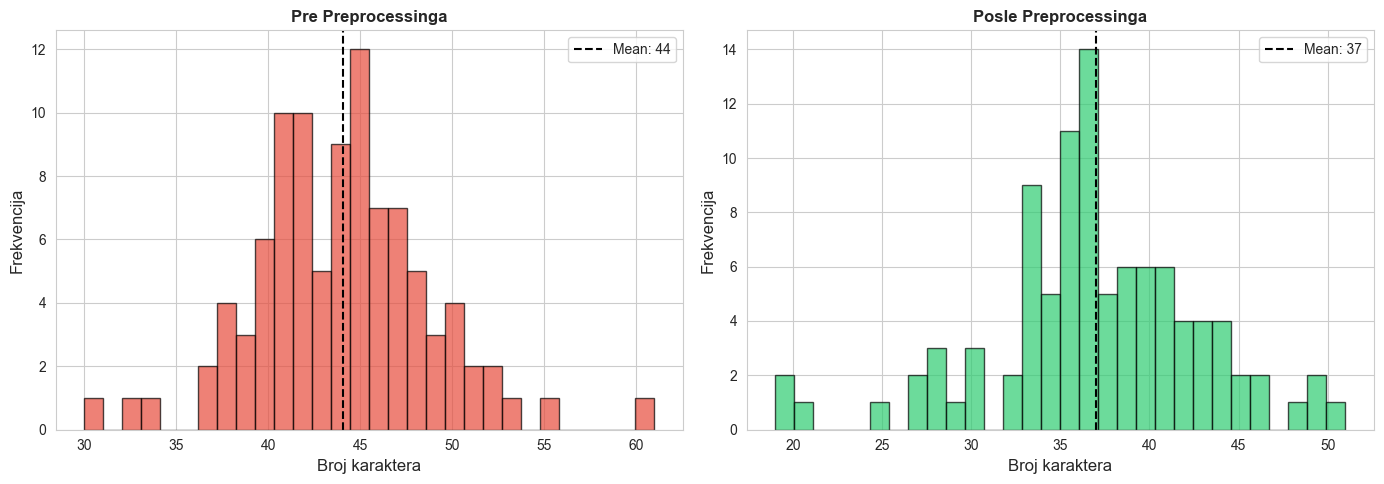

In [11]:
# Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pre
axes[0].hist(df['original_length'], bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0].axvline(df['original_length'].mean(), color='black', linestyle='--', 
                label=f"Mean: {df['original_length'].mean():.0f}")
axes[0].set_title('Pre Preprocessinga', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Broj karaktera')
axes[0].set_ylabel('Frekvencija')
axes[0].legend()

# Posle
axes[1].hist(df['cleaned_length'], bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1].axvline(df['cleaned_length'].mean(), color='black', linestyle='--', 
                label=f"Mean: {df['cleaned_length'].mean():.0f}")
axes[1].set_title('Posle Preprocessinga', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Broj karaktera')
axes[1].set_ylabel('Frekvencija')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Train/Test Split

In [12]:
# Proveri da li postoji sentiment kolona
if SENTIMENT_COLUMN not in df.columns:
    print("❌ GREŠKA: Nema sentiment kolone!")
    print("Moraš imati labelovane podatke za treniranje modela.")
else:
    print("✅ Sentiment kolona pronađena!\n")
    
    # Pripremi X i y
    X = df['cleaned_text']
    y = df[SENTIMENT_COLUMN]
    
    print(f"Ukupno primeraka: {len(X)}")
    print(f"\nDistribucija sentimenta:")
    print(y.value_counts())
    print(f"\nProcenat:")
    print((y.value_counts() / len(y) * 100).round(2))

✅ Sentiment kolona pronađena!

Ukupno primeraka: 97

Distribucija sentimenta:
sentiment
positive    33
negative    32
neutral     32
Name: count, dtype: int64

Procenat:
sentiment
positive    34.02
negative    32.99
neutral     32.99
Name: count, dtype: float64


In [13]:
# Split 80/20 sa stratification (čuva distribuciju sentimenta)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("\n📊 TRAIN/TEST SPLIT")
print("="*50)
print(f"\nTrain set: {len(X_train)} primeraka ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set:  {len(X_test)} primeraka ({len(X_test)/len(X)*100:.1f}%)")

print("\n📈 Distribucija u TRAIN set-u:")
print(y_train.value_counts())
print(f"\nProcenat:")
print((y_train.value_counts() / len(y_train) * 100).round(2))

print("\n📈 Distribucija u TEST set-u:")
print(y_test.value_counts())
print(f"\nProcenat:")
print((y_test.value_counts() / len(y_test) * 100).round(2))


📊 TRAIN/TEST SPLIT

Train set: 77 primeraka (79.4%)
Test set:  20 primeraka (20.6%)

📈 Distribucija u TRAIN set-u:
sentiment
positive    26
neutral     26
negative    25
Name: count, dtype: int64

Procenat:
sentiment
positive    33.77
neutral     33.77
negative    32.47
Name: count, dtype: float64

📈 Distribucija u TEST set-u:
sentiment
negative    7
positive    7
neutral     6
Name: count, dtype: int64

Procenat:
sentiment
negative    35.0
positive    35.0
neutral     30.0
Name: count, dtype: float64


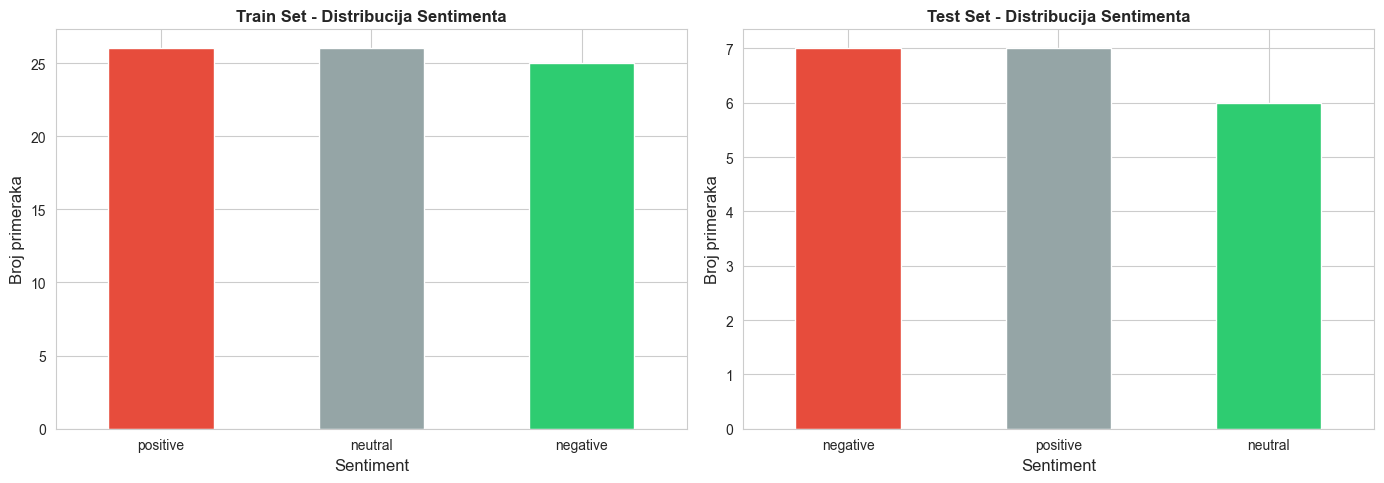

In [14]:
# Vizualizacija distribucije
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[0].set_title('Train Set - Distribucija Sentimenta', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Broj primeraka')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Test
y_test.value_counts().plot(kind='bar', ax=axes[1], color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[1].set_title('Test Set - Distribucija Sentimenta', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Broj primeraka')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 7. Čuvanje Preprocesiranih Podataka

In [15]:
# Sačuvaj train podatke
train_df = pd.DataFrame({
    'text': X_train,
    'sentiment': y_train
})

train_path = '../data/processed/train_data.csv'
train_df.to_csv(train_path, index=False)
print(f"✅ Train data sačuvana: {train_path}")
print(f"   Dimenzije: {train_df.shape}")

✅ Train data sačuvana: ../data/processed/train_data.csv
   Dimenzije: (77, 2)


In [16]:
# Sačuvaj test podatke
test_df = pd.DataFrame({
    'text': X_test,
    'sentiment': y_test
})

test_path = '../data/processed/test_data.csv'
test_df.to_csv(test_path, index=False)
print(f"✅ Test data sačuvana: {test_path}")
print(f"   Dimenzije: {test_df.shape}")

✅ Test data sačuvana: ../data/processed/test_data.csv
   Dimenzije: (20, 2)


In [17]:
# Sačuvaj i ceo preprocesiran dataset (za reference)
full_path = '../data/processed/bitcoin_tweets_preprocessed.csv'
df[['cleaned_text', SENTIMENT_COLUMN]].to_csv(full_path, index=False)
print(f"\n✅ Celokupan preprocesiran dataset sačuvan: {full_path}")
print(f"   Dimenzije: {df.shape}")


✅ Celokupan preprocesiran dataset sačuvan: ../data/processed/bitcoin_tweets_preprocessed.csv
   Dimenzije: (97, 9)


## 8. Finalna Provera

In [18]:
# Provera sačuvanih fajlova
import os

print("\n📁 SAČUVANI FAJLOVI")
print("="*50)

files_to_check = [
    '../data/processed/train_data.csv',
    '../data/processed/test_data.csv',
    '../data/processed/bitcoin_tweets_preprocessed.csv'
]

for filepath in files_to_check:
    if os.path.exists(filepath):
        size = os.path.getsize(filepath) / 1024  # KB
        print(f"✅ {filepath}")
        print(f"   Veličina: {size:.2f} KB")
    else:
        print(f"❌ {filepath} - NE POSTOJI!")


📁 SAČUVANI FAJLOVI
✅ ../data/processed/train_data.csv
   Veličina: 3.64 KB
✅ ../data/processed/test_data.csv
   Veličina: 0.91 KB
✅ ../data/processed/bitcoin_tweets_preprocessed.csv
   Veličina: 4.54 KB


In [19]:
# Test učitavanja
print("\n🧪 TEST UČITAVANJA")
print("="*50)

try:
    test_train = pd.read_csv('../data/processed/train_data.csv')
    print(f"✅ Train data učitana: {test_train.shape}")
    print(f"   Kolone: {test_train.columns.tolist()}")
    
    test_test = pd.read_csv('../data/processed/test_data.csv')
    print(f"\n✅ Test data učitana: {test_test.shape}")
    print(f"   Kolone: {test_test.columns.tolist()}")
    
    print("\n🎉 SVE JE SPREMNO ZA MODELOVANJE!")
except Exception as e:
    print(f"\n❌ Greška pri učitavanju: {e}")


🧪 TEST UČITAVANJA
✅ Train data učitana: (77, 2)
   Kolone: ['text', 'sentiment']

✅ Test data učitana: (20, 2)
   Kolone: ['text', 'sentiment']

🎉 SVE JE SPREMNO ZA MODELOVANJE!


## 📝 Zaključak Notebook-a 02

**Urađeno**:
- ✅ Preprocessing tekstualnih podataka (cleaning, tokenization, lemmatization)
- ✅ Kreiran train/test split (80/20) sa stratification
- ✅ Sačuvani preprocesirani podaci
- ✅ Validacija sačuvanih fajlova

**Statistika**:
- Train set: {} primeraka
- Test set: {} primeraka
- Redukcija dužine teksta: ~{}%

**Sledeći korak**: Notebook 03 - Baseline modeli (Naive Bayes, SVM)